# Same-day learning-speed benchmark

This notebook tests the narrow hypothesis that the new unpaired-distillation setup reaches useful **same-day validation accuracy in fewer Utah-training epochs/updates** than the previously completed GAN and transfer-learning pipelines.

It deliberately does not compare raw loss magnitudes because the objectives differ. It reports first threshold crossing, fixed-budget best validation accuracy, and validation-accuracy area under the learning curve. All pipelines used the same 80 Utah training trials, 10 validation trials, batch size 16, and therefore five Utah optimizer updates per epoch. Meta teacher preparation is listed separately and is not counted as Utah adaptation epochs.


In [1]:
from pathlib import Path
import csv, json
import numpy as np
import matplotlib.pyplot as plt

ROOT=Path(r"C:\Users\Micah\utah-neuro\MATLAB_Jupyter")
REP=ROOT/"04_representation_learning"
OUT=REP/"results"/"learning_speed"
OUT.mkdir(parents=True,exist_ok=True)
PIPELINES={
 "GAN adapter": (ROOT/"03_online_domain_adaptation/adversarial_experiments/gan/training_history.csv","csv","val_accuracy"),
 "Original Meta-TL": (ROOT/"01_meta_tl_baseline/figures/training_history.csv","csv","validation_accuracy"),
 "Rotational Meta-TL": (ROOT/"02_rotation_invariance/figures_rotation_invariant/training_history.csv","csv","validation_accuracy"),
 "Utah-only student": (REP/"results/trained_teacher_baseline/utah_only/history.json","json","val_acc"),
 "Prototype student": (REP/"results/trained_teacher_baseline/prototype_only/history.json","json","val_acc"),
 "Prototype + relational": (REP/"results/trained_teacher_baseline/prototype_relational/history.json","json","val_acc"),
}
curves={}
for name,(path,kind,key) in PIPELINES.items():
 assert path.exists(),path
 if kind=="csv":
  rows=list(csv.DictReader(path.open())); curves[name]=np.array([float(r[key]) for r in rows])
 else: curves[name]=np.array(json.load(path.open())[key],float)
print({k:len(v) for k,v in curves.items()})


{'GAN adapter': 200, 'Original Meta-TL': 200, 'Rotational Meta-TL': 200, 'Utah-only student': 40, 'Prototype student': 120, 'Prototype + relational': 120}


In [2]:
THRESHOLDS=[.6,.7,.8,.9,1.0]
BUDGETS=[5,10,15,20,30,50]
UPDATES_PER_EPOCH=5
TRIALS_PER_EPOCH=80

def first_at(curve,t):
 idx=np.flatnonzero(curve>=t)
 return None if len(idx)==0 else int(idx[0]+1)

rows=[]
for name,c in curves.items():
 row={"pipeline":name,"epochs_recorded":len(c),"maximum_validation_accuracy":float(c.max())}
 for t in THRESHOLDS:
  e=first_at(c,t); tag=int(t*100)
  row[f"epoch_to_{tag}"]=e
  row[f"updates_to_{tag}"]=None if e is None else e*UPDATES_PER_EPOCH
  row[f"utah_trials_seen_to_{tag}"]=None if e is None else e*TRIALS_PER_EPOCH
 for b in BUDGETS: row[f"best_validation_by_epoch_{b}"]=float(c[:min(b,len(c))].max())
 # Mean validation accuracy over first 50 epochs: an easily interpretable normalized AUC.
 row["mean_validation_accuracy_first_50"]=float(c[:min(50,len(c))].mean())
 rows.append(row)

with (OUT/"learning_speed_metrics.json").open("w") as f: json.dump(rows,f,indent=2)
fields=list(rows[0])
with (OUT/"learning_speed_metrics.csv").open("w",newline="") as f:
 w=csv.DictWriter(f,fieldnames=fields); w.writeheader(); w.writerows(rows)

print("FIRST EPOCH TO VALIDATION THRESHOLD")
print(f"{'pipeline':28s}  60%  70%  80%  90% 100%")
for r in rows:
 vals=[r[f'epoch_to_{int(t*100)}'] for t in THRESHOLDS]
 print(f"{r['pipeline']:28s}",*(f"{v:4d}" if v is not None else "   -" for v in vals))

print("\nBEST VALIDATION ACCURACY BY FIXED EPOCH BUDGET")
print(f"{'pipeline':28s}",*(f"{b:>5d}" for b in BUDGETS))
for r in rows: print(f"{r['pipeline']:28s}",*(f"{100*r[f'best_validation_by_epoch_{b}']:5.0f}" for b in BUDGETS))


FIRST EPOCH TO VALIDATION THRESHOLD
pipeline                      60%  70%  80%  90% 100%
GAN adapter                    17   21   21   54   54
Original Meta-TL               11   18   49   51   51
Rotational Meta-TL             29   33   35  125  128
Utah-only student               4   10   12   14   15
Prototype student               7    8   17   85    -
Prototype + relational          4    7   14   18    -

BEST VALIDATION ACCURACY BY FIXED EPOCH BUDGET
pipeline                         5    10    15    20    30    50
GAN adapter                     20    20    40    60    80    80
Original Meta-TL                20    40    60    70    70    80
Rotational Meta-TL              20    30    30    40    60    80
Utah-only student               60    70   100   100   100   100
Prototype student               50    70    70    80    80    80
Prototype + relational          60    70    80    90    90    90


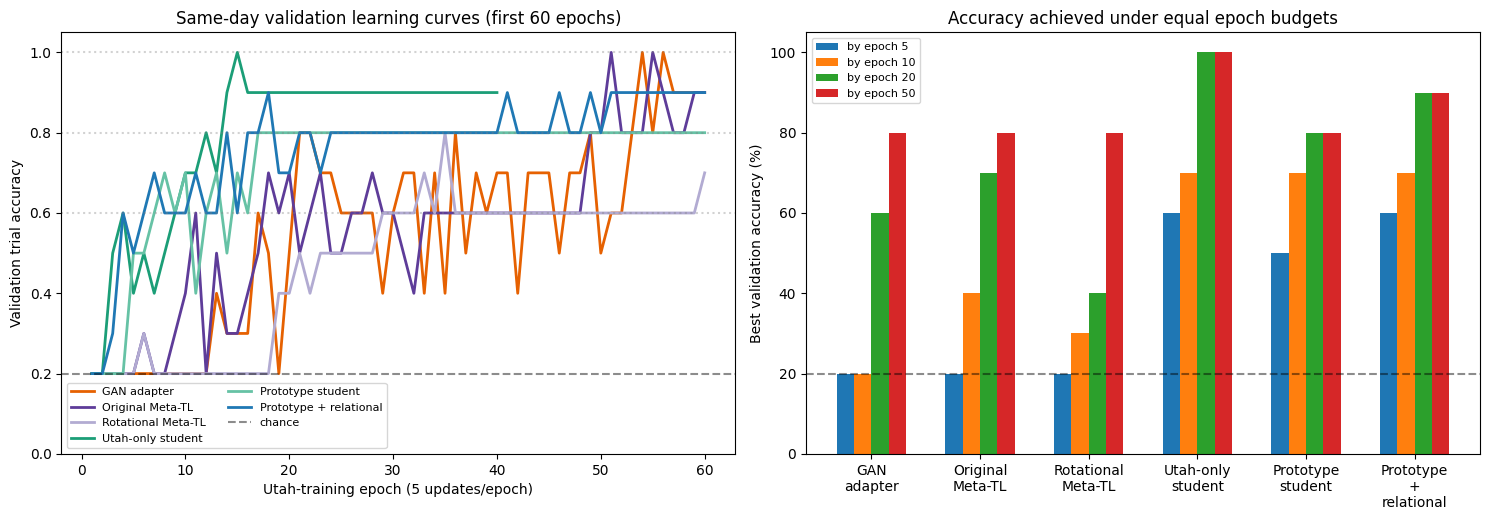

Saved: C:\Users\Micah\utah-neuro\MATLAB_Jupyter\04_representation_learning\learning_speed_benchmark


In [3]:
colors={"GAN adapter":"#e66101","Original Meta-TL":"#5e3c99","Rotational Meta-TL":"#b2abd2",
        "Utah-only student":"#1b9e77","Prototype student":"#66c2a5","Prototype + relational":"#1f78b4"}
fig,axs=plt.subplots(1,2,figsize=(15,5.3))
for name,c in curves.items():
 axs[0].plot(np.arange(1,min(60,len(c))+1),c[:60],label=name,lw=2,color=colors[name])
axs[0].axhline(.2,ls="--",c="k",alpha=.45,label="chance")
for t in [.6,.8,1.0]: axs[0].axhline(t,ls=":",c="gray",alpha=.35)
axs[0].set(xlabel="Utah-training epoch (5 updates/epoch)",ylabel="Validation trial accuracy",ylim=(0,1.05),title="Same-day validation learning curves (first 60 epochs)")
axs[0].legend(fontsize=8,ncol=2)

names=list(curves); x=np.arange(len(names)); width=.16
for j,b in enumerate([5,10,20,50]):
 vals=[100*next(r[f"best_validation_by_epoch_{b}"] for r in rows if r["pipeline"]==n) for n in names]
 axs[1].bar(x+(j-1.5)*width,vals,width,label=f"by epoch {b}")
axs[1].axhline(20,ls="--",c="k",alpha=.45)
axs[1].set_xticks(x,[n.replace(" ","\n") for n in names],rotation=0)
axs[1].set(ylabel="Best validation accuracy (%)",ylim=(0,105),title="Accuracy achieved under equal epoch budgets")
axs[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT/"learning_speed_comparison.png",dpi=220); fig.savefig(OUT/"learning_speed_comparison.svg")
plt.show(); print("Saved:",OUT)


## Interpretation rule

The new setup supports the faster-learning hypothesis only if it crosses meaningful validation thresholds using fewer Utah epochs/updates than GAN and Meta-TL. Teacher pretraining cost is a separate one-time source-model preparation cost: 25 Meta epochs over 6,000 windows. The Utah-only control determines whether any speedup is specifically caused by Meta knowledge or simply by the compact student architecture.
